# 📊 ACFX: Causal Feature Exploration on Health Datasets

Welcome to this Jupyter Notebook showcasing **ACFX (Automated Causal Feature Exploration)** for the purpose of a ACFX survey [LINK].
For the purpose of this survey, I prepared and attached an examplary dataset (German credit data is a dataset by Hofmann, H. (1994). Statlog (German Credit Data) UCI Machine Learning Repository. https://doi.org/10.24432/C5NC77).


## 🔍 Purpose of this Notebook

The goal of this notebook is to:
- **Load and preprocess** the datasets.
- **Split** into training and testing sets with stratification for reproducibility.
- **Explore causal relationships** among features using ACfX.
- **Visualize causal graphs** to uncover dependencies and potential actionable insights.
- Enable you to **answer questions of the survey** regarding your opinions of the framework.

By the end of this notebook, you will be able to:

- Identify **key causal relationships** in the data.  
- Understand **feature importance from a causal perspective**, not just correlation.  
- Generate **graphical visualizations** of the learned causal structures.  

---

### ⚙️ Configuration

Before diving in, all parameters for data loading, test/train splitting, and causal analysis are defined at the top of the notebook so you can **easily adjust the behavior** without modifying the core functions.

In [98]:
!python --version

Python 3.11.15


In [99]:
!pip install acfx==0.3.6

In [100]:
!pip install ipywidgets pydot

In [117]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 10.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyvis]


In ACFX framework, there are three explainers available for evaluation:
1. AcfxEBM, for interpret.glassbox's ExplainableBoostingClassifier blackbox
2. AcfxLinear, for scikit-learn's LinearClassifierMixin (linear classifier with linear coeffs- LogisticRegressionCounterOptimizer is recommended here)
3. AcfxCustom, for the use of any custom blackbox (requires providing compatible counter-optimizer)

For the purpose of this survey, we will stick to the EBM blackbox and the german credit dataset

To initialize the explainer with its blackbox, run:

In [105]:
from acfx import AcfxEBM
from interpret.glassbox import ExplainableBoostingClassifier
from dataset.column_types import feature_types

no_target_feature_types = [
    v for k, v in feature_types.items() if k != 'Credit granted'
]

categorical_indicator = [
    True if v != 'continuous' else False
    for k, v in feature_types.items()
    if k != 'Credit granted'
]

model = ExplainableBoostingClassifier(
    # Can be: 'continuous', 'nominal', or 'ordinal'
    feature_types=no_target_feature_types)
explainer = AcfxEBM(model)

In [106]:
import pandas as pd
file_path = './dataset/german_credit_numeric.csv'

In [107]:
bunch_df = pd.read_csv(file_path)

In [108]:
bunch_df

,Status of existing checking account,Duration,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,Property,Age,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,foreign worker,Credit granted
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,1
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,0
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,1
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,1
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,12,2,3,1736,0,3,3,1,0,...,0,31,2,1,1,1,1,0,0,1
996,0,30,2,1,3857,0,2,4,0,0,...,1,40,2,1,1,3,1,1,0,1
997,3,12,2,4,804,0,4,4,2,0,...,2,38,2,1,1,2,1,0,0,1
998,0,45,2,4,1845,0,2,4,2,0,...,3,23,2,2,1,2,1,1,0,0


In [109]:
y = bunch_df['Credit granted']
y

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Credit granted, Length: 1000, dtype: int64

In [110]:
X = bunch_df.drop('Credit granted', axis=1)
X

,Status of existing checking account,Duration,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,Present residence since,Property,Age,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,foreign worker
0,0,6,4,4,1169,4,4,4,2,0,4,0,67,2,1,2,2,1,1,0
1,1,48,2,4,5951,0,2,2,1,0,2,0,22,2,1,1,2,1,0,0
2,3,12,4,7,2096,0,3,2,2,0,3,0,49,2,1,1,1,2,0,0
3,0,42,2,3,7882,0,3,2,2,2,4,1,45,2,2,1,2,2,0,0
4,0,24,3,0,4870,0,2,3,2,0,4,3,53,2,2,2,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,12,2,3,1736,0,3,3,1,0,4,0,31,2,1,1,1,1,0,0
996,0,30,2,1,3857,0,2,4,0,0,4,1,40,2,1,1,3,1,1,0
997,3,12,2,4,804,0,4,4,2,0,4,2,38,2,1,1,2,1,0,0
998,0,45,2,4,1845,0,2,4,2,0,4,3,23,2,2,1,2,1,1,0


In [111]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.1,
random_state=433
)

In [112]:
model.fit(X=X_train, y=y_train)

/home/user/anaconda3/envs/ccfenv13/lib/python3.11/site-packages/interpret/utils/_clean_x.py:793: UserWarning: During fitting you should usually specify the ordered strings instead of specifying 'ordinal' as the feature type. When 'ordinal' is specified then alphabetic ordering is used.
  warn(
INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST
INFO:interpret.glassbox._ebm._boost:Start boosting
INFO:interpret.utils._native:Booster allocation start
INFO:interpret.utils._native:Booster allocation end
INFO:interpret.utils._native:Deallocation boosting start
INFO:interpret.utils._native:Deallocation boosting end


ExplainableBoostingClassifier(feature_types=['ordinal', 'continuous', 'ordinal',
                                             'nominal', 'continuous', 'ordinal',
                                             'ordinal', 'continuous', 'nominal',
                                             'nominal', 'continuous', 'nominal',
                                             'continuous', 'nominal', 'nominal',
                                             'ordinal', 'ordinal', 'ordinal',
                                             'nominal', 'nominal'])

In [113]:
from graphviz import Source
from IPython.display import display
from acfx.evaluation.bayesian_model import train_bayesian_model

num_bins = 3
bayesian_model = train_bayesian_model(X_train, categorical_indicator, num_bins)

nodes = list(bayesian_model.nodes)
edges = list(bayesian_model.edges)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Status of existing checking account': 'N', 'Duration': 'N', 'Credit history': 'N', 'Purpose': 'N', 'Credit amount': 'N', 'Savings account/bonds': 'N', 'Present employment since': 'N', 'Installment rate in percentage of disposable income': 'N', 'Personal status and sex': 'N', 'Other debtors / guarantors': 'N', 'Present residence since': 'N', 'Property': 'N', 'Age': 'N', 'Other installment plans': 'N', 'Housing': 'N', 'Number of existing credits at this bank': 'N', 'Job': 'N', 'Number of people being liable to provide maintenance for': 'N', 'Telephone': 'N', 'foreign worker': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Status of existing checking account': 'N', 'Duration': 'N', 'Credit history': 'N', 'Purpose': 'N', 'Credit amount': 'N', 'Savings account/bonds': 'N', 'Present employment since': 'N', 'Installment rat

/tmp/ipykernel_10753/95008961.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


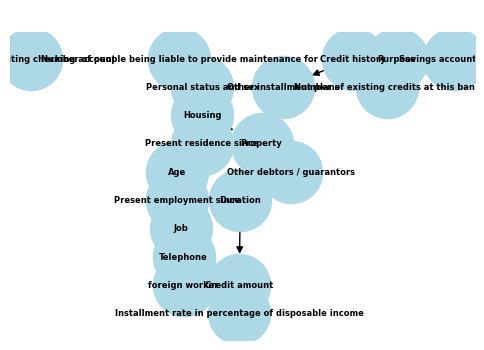

In [114]:
import networkx as nx
G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

In [119]:
from pyvis.network import Network
import networkx as nx

# 1. Inicjalizacja interaktywnej sieci
net = Network(notebook=True, directed=True, height="600px", width="100%", bgcolor="#222222", font_color="white")

net.from_nx(G)
net.toggle_physics(True)
net.show_buttons(filter_=['physics'])
net.show("bayesian_network.html")

bayesian_network.html


In [115]:
causal_order = list(nx.topological_sort(G))
print("Causal order:", causal_order)

Causal order: ['Status of existing checking account', 'Credit history', 'Purpose', 'Savings account/bonds', 'Number of people being liable to provide maintenance for', 'Number of existing credits at this bank', 'Other installment plans', 'Personal status and sex', 'Housing', 'Property', 'Present residence since', 'Duration', 'Other debtors / guarantors', 'Age', 'Present employment since', 'Job', 'Telephone', 'Credit amount', 'foreign worker', 'Installment rate in percentage of disposable income']


In [123]:
from IPython.display import display, Markdown
limit = 3

for i, cpd in enumerate(bayesian_model.get_cpds()):
    # comment to display all
    if limit == i:
        break

    if not cpd:
        continue
    try:
        df = cpd.to_dataframe()

        display(Markdown("---"))

        display(Markdown(f"### CPD of Variable: **{cpd.variable}**"))

        evidence = cpd.get_evidence()
        if evidence:
            display(Markdown(f"*Conditioned on (Evidence):* `{', '.join(evidence)}`"))
        else:
            display(Markdown(f"*Prior Probability (Root Node - No Evidence)*"))

        display(df)

    except Exception as e:
        print(f"Error rendering CPD for {cpd.variable}: {e}")
        continue

---

### CPD of Variable: **Duration**

*Conditioned on (Evidence):* `Property`

Duration,0,1,2
Property,,,
0,0.892223,0.098419,0.009358
1,0.798105,0.185002,0.016893
2,0.713658,0.278373,0.007969
3,0.618879,0.321534,0.059587


---

### CPD of Variable: **Credit amount**

*Conditioned on (Evidence):* `Telephone, Duration`

Credit amount              0         1         2
Duration Telephone                              
0        0          0.980459  0.018906  0.000634
         1          0.893126  0.090282  0.016591
1        0          0.726722  0.260606  0.012672
         1          0.482154  0.449486  0.068361
2        0          0.290780  0.673759  0.035461
         1          0.031447  0.484277  0.484277

Error rendering CPD for Credit history: zero-size array to reduction operation maximum which has no identity


In [ ]:
features_order = X_train_scaled.columns.tolist()

query_instance = X_train_scaled.sample(1).values


explainer.fit(X=X_train_scaled, adjacency_matrix=adjacency_matrix, causal_order=causal_order, pbounds=pbounds,
              y=y_train, features_order=features_order)